# **DNA Knot Simulation - Part 1: The Polymer Simulator**
*Course-grained bead-spring DNA under Langevin Dynamics*


This is the first of a multi-part project studyign knotting in DNA computationally. We describe and implement the standard course-grained bead-spring model for DNA and the potentials involved (FENE bonds, Lennard-Jones excluded volume, Kratky Porod bending)

# **A. The physical model**

DNA is represented as a closed chain of $N$ beads (a ring polymer; matching circular DNA in prokaryotic cells). Four potential act on it:

**1. FENE Bonds** (chain connectivity, finite extensibility) - keeps consecutive beads connected without letting the bonds stretch indefinitely:
$$E_{\text{FENE}}(r) = -\tfrac{1}{2} K R_0^2 \ln\!\left(1 - (r/R_0)^2\right)$$
Force diverges as $r \to R_0$, which is what enforces finite extensibility (a bond physically cannot stretch past $R_0$)

**2. WCA Excluded Volume** (purely repulsive Lennard-Jones, cut at the potential minimum) - gives the chain physical thickness so it cannot pass through itself:
$$E_{\text{WCA}}(r) = 4\epsilon\left[(\sigma/r)^{12} - (\sigma/r)^6\right] + \epsilon,\quad r < 2^{1/6}\sigma$$
Without excluded volume, "knotted" and "unknotted" are not well defined for a continuous-time simulation. Nothing stops two strands from drifting through each other, destroying or creating a knot with zero energy cost. WCA is what makes topology a meaningfull, conserved quantity.

**3. Kratky-Porod bending stifffness** (controls persistence length/flexibility):
$$E_{\text{bend}} = \kappa \sum_i (1 - \cos\theta_i)$$
where $\theta_i$ is the angle at bead $i$ between its incoming and outgoing bonds. $\kappa= 0$ is a fully flexible chain; higher $\kappa$ resists bending, controlling how readily the chain knots itself (stiffer chains knot less easily (relevant for notebook 5's confinement study))

**4. Spherical confinement** - a soft harmonic wall beyond a given radius, modelling packing into a nucleus or viral capsid.

All quantities use standard reduced (Lennard-Jones) units: $\sigma=1$ (bead diameter),
$\epsilon=1$ (energy scale), $k_BT=1$.

**On the dynamics:** We use the overdamped (Brownian dynamics) Langevin equation, which drops inertia:
$$dr = \frac{1}{\gamma}F(r)\,dt + \sqrt{\frac{2k_BT\,dt}{\gamma}}\,\xi,$$
This is a deliberate modelling choice, not a simplification for convenience. DNA beads at this scale are deep in the low-Reynolds-number regime, where viscous drag dominates inertial effects. This is the standard choice in many DNA/polymer knot simulation literature such as
[Vologodskii](https://link.springer.com/chapter/10.1007/978-3-540-49858-2_3).

# **B. Setup**

In [ ]:
import sys, os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    REPO_URL = "https://github.com/vanikumar03/dna-knots.git"
    REPO_PATH = "/content/dna-knots"
    if not os.path.isdir(REPO_PATH):
        os.system(f"git clone {REPO_URL} {REPO_PATH}")
    os.chdir(f"{REPO_PATH}/notebooks")

sys.path.append(os.path.join(REPO_PATH, 'src') if IN_COLAB else os.path.join('..', 'src'))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import dnasim as ds

# **C. Verifying every force**

Each potential above has a hand-derived analytic force. Before running any simulation, every one of them is checked against a finite-difference gradient of its own energy function, i.e., $F = -\nabla E$ must hold to numerical precision. Otherwise, the force implemetation has a bug, independent of how physically plausible a resulting trajectory might look.

On running this check we found:
1. The FENE force had an extra, false division by bond length $r$. The correct force is $\frac{K}{1-(r/R_0)^2}\,\vec{r}_{\text{bond}}$ using the raw bond vector. The $r$ from $dE/dr$ and the $r$ from $dr/dx$ cancel exactly, but it is easy to divide by $r$ a second time out of habit from unit-vector force calculations.
2. The bending force's per-bead gradient terms had their signs swapped between the "previous bead" and the "next-bead" contributions.

Both are fixed in `dnasim.py`; the check below is run here so the fix is verified in the notebook.

In [ ]:
def numerical_gradient(energy_fn, positions, h=1e-6, **kwargs):
    grad = np.zeros_like(positions)
    for i in range(positions.shape[0]):
        for d in range(3):
            p_plus = positions.copy(); p_plus[i, d] += h
            p_minus = positions.copy(); p_minus[i, d] -= h
            grad[i, d] = (energy_fn(p_plus, **kwargs) - energy_fn(p_minus, **kwargs)) / (2 * h)
    return grad

In [ ]:
rng = np.random.default_rng(42)
test_positions = ds.make_ring(20, seed=1)
test_positions += rng.normal(scale=0.1, size=test_positions.shape)  # break symmetry

tests = [
    ('FENE',        ds.fene_energy,        ds.fene_force,        dict(K=30.0, R0=1.5)),
    ('WCA',         ds.wca_energy,         ds.wca_force,         dict(epsilon=1.0, sigma=1.0)),
    ('Bending',     ds.bending_energy,     ds.bending_force,     dict(kappa=2.0)),
    ('Confinement', ds.confinement_energy, ds.confinement_force, dict(radius=2.0, strength=50.0)),
]

print(f'{"Force":<14}{"max abs err":>14}{"max rel err":>14}   result')
for name, efn, ffn, kwargs in tests:
    test_pos = test_positions * (3 if name == 'Confinement' else 1)  # push some beads outside confinement radius
    analytic = ffn(test_pos, **kwargs)
    numeric_grad = numerical_gradient(efn, test_pos, **kwargs)
    expected = -numeric_grad
    max_err = np.max(np.abs(analytic - expected))
    rel_err = max_err / (np.max(np.abs(expected)) + 1e-10)
    status = 'PASS' if rel_err < 1e-4 else 'FAIL'
    print(f'{name:<14}{max_err:>14.2e}{rel_err:>14.2e}   {status}')

Force            max abs err   max rel err   result
FENE                8.37e-08      7.82e-10   PASS
WCA                 1.17e-07      6.96e-11   PASS
Bending             7.39e-10      2.41e-10   PASS
Confinement         2.12e-06      5.50e-09   PASS


# **D. Finding a numerically stable timestep**

Explicit Euler-Maruyama integration of a stiff potential (FENE diverges as $r \to R_0$) can blow up if the timestep is too large. A noise-driven bond that randomly stretches close to $R_0$ produces a huge force, which produces a huge displacement, which produces a more huge force at the next step. This is a numerical stability questions, not a modelling one. We thus test it, rather than guessing a $dt$.

In [ ]:
N = 40
for dt in [0.002, 0.0005, 0.0001, 0.00005]:
    pos0 = ds.make_ring(N, bond_length=1.0, seed=0)
    test_rng = np.random.default_rng(1)
    pos = pos0.copy()
    blew_up_at = None
    for step in range(1, 2001):
        pos = ds.langevin_step(pos, dt, gamma=1.0, kT=1.0, rng=test_rng,
                                K=30.0, R0=1.5, epsilon=1.0, sigma=1.0, kappa=0.0)
        if np.isnan(pos).any() or np.isinf(pos).any():
            blew_up_at = step
            break
    status = f'blew up at step {blew_up_at} (t={blew_up_at*dt:.4f})' if blew_up_at \
             else f'stable through 2000 steps (t={2000*dt:.3f})'
    print(f'dt={dt:<10} {status}')

dt=0.002      blew up at step 60 (t=0.1200)
dt=0.0005     blew up at step 93 (t=0.0465)


/usr/local/lib/python3.12/dist-packages/numpy/linalg/_linalg.py:2803: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real
/usr/local/lib/python3.12/dist-packages/numpy/linalg/_linalg.py:2804: RuntimeWarning: overflow encountered in reduce
  return sqrt(add.reduce(s, axis=axis, keepdims=keepdims))
/home/claude/dna-knots/notebooks/../src/dnasim.py:61: RuntimeWarning: overflow encountered in multiply
  bond_force = mag[:, None] * bonds  # points i -> i+1
/home/claude/dna-knots/notebooks/../src/dnasim.py:65: RuntimeWarning: invalid value encountered in subtract
  forces -= np.roll(bond_force, 1, axis=0)    # pulls bead i towards i-1
/home/claude/dna-knots/notebooks/../src/dnasim.py:65: RuntimeWarning: overflow encountered in subtract
  forces -= np.roll(bond_force, 1, axis=0)    # pulls bead i towards i-1


dt=0.0001     stable through 2000 steps (t=0.200)


dt=5e-05      stable through 2000 steps (t=0.100)


`dt=0.0001` is the largest of the tested values that stays stable — used as the default
for every run in this notebook (and downstream notebooks) going forward.

# **E. Running the simulation: a flexible ring**

In [ ]:
N = 40
pos0 = ds.make_ring(N, bond_length=1.0, seed=0)

trajectory = ds.run_simulation(
    pos0, n_steps=100000, dt=0.0001, gamma=1.0, kT=1.0, seed=1, record_every=5000,
    K=30.0, R0=1.5, epsilon=1.0, sigma=1.0, kappa=0.0
)
print(f'{len(trajectory)} snapshots recorded')

21 snapshots recorded


### Diagnostics over time

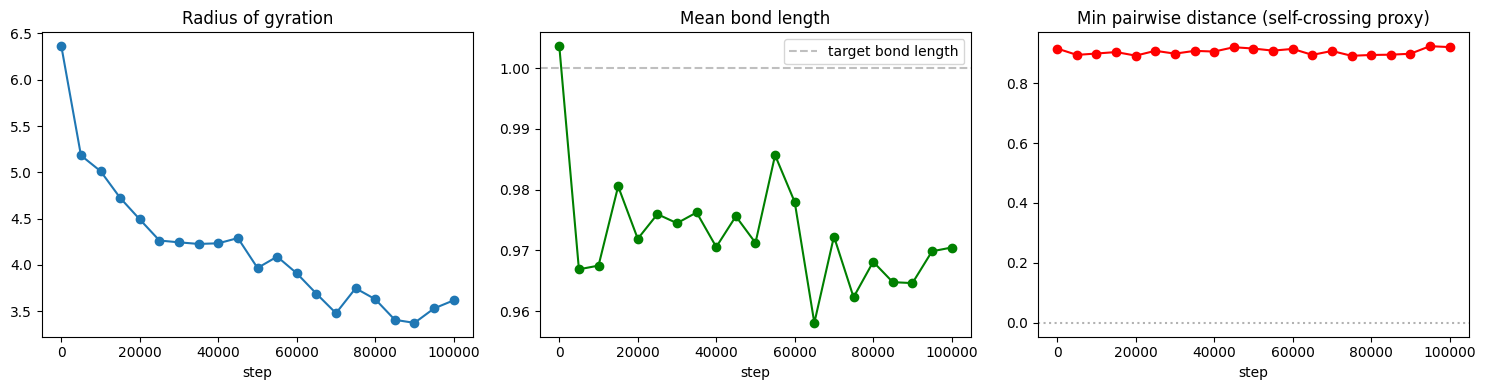

In [ ]:
steps = np.arange(len(trajectory)) * 5000
rg_vals = [ds.radius_of_gyration(p) for p in trajectory]
bond_means = [ds.bond_length_stats(p)[0] for p in trajectory]
min_dists = [ds.min_pairwise_distance(p) for p in trajectory]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(steps, rg_vals, marker='o')
axes[0].set_title('Radius of gyration'); axes[0].set_xlabel('step')

axes[1].plot(steps, bond_means, marker='o', color='green')
axes[1].axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='target bond length')
axes[1].set_title('Mean bond length'); axes[1].set_xlabel('step'); axes[1].legend()

axes[2].plot(steps, min_dists, marker='o', color='red')
axes[2].axhline(0, color='black', linestyle=':', alpha=0.3)
axes[2].set_title('Min pairwise distance (self-crossing proxy)'); axes[2].set_xlabel('step')

plt.tight_layout()
plt.show()

$R_g$ starts high (the initial configuration is an artificially stretched-out circle) and relaxes down to a smaller, fluctuating equilibrium size as the chain finds its natural coiled conformation. This is the expected physical behaviour for a flexible self-avoiding ring, relaxing from a non-equilibrium start. Mean bond length should stay tightly clustered near the target (FENE holding the chain together correctly), and the min pairwise distance should stay safely above 0 throughout (WCA preventing collapse/self-crossing). If this ever approaches 0, it indicates the beads are about to pass though each other, corrupting the chain's topology.

### Visualize the final configuration

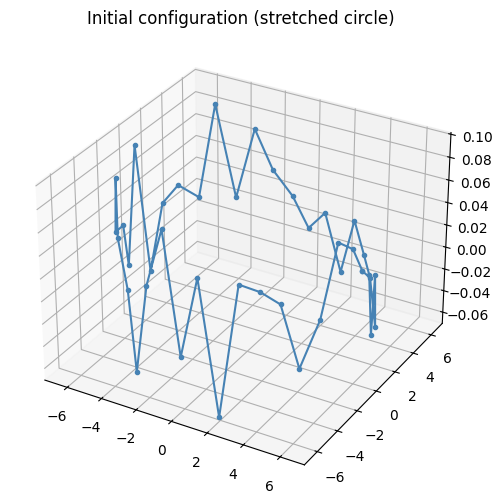

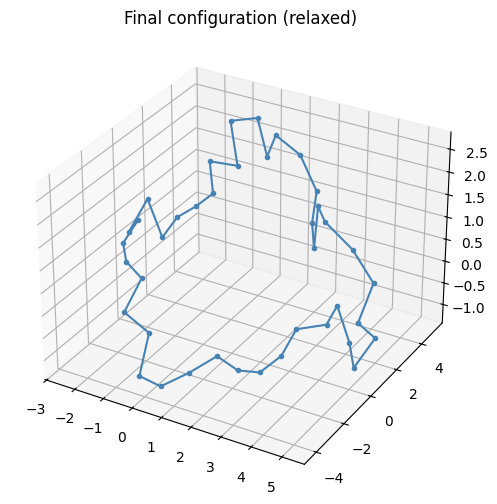

In [ ]:
def plot_chain_3d(positions, title='', ax=None, color='steelblue'):
    close_loop = np.vstack([positions, positions[0]])
    if ax is None:
        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection='3d')
    ax.plot(close_loop[:, 0], close_loop[:, 1], close_loop[:, 2], '-o',
            color=color, markersize=3, linewidth=1.5)
    ax.set_title(title)
    return ax

plot_chain_3d(trajectory[0], title='Initial configuration (stretched circle)')
plt.show()
plot_chain_3d(trajectory[-1], title='Final configuration (relaxed)')
plt.show()

# **F. Semi-flexible ring (bending stiffness)**


Repeating with $\kappa > 0$. The chain should resist tight turns and show visibly less coiling than the fully flexible case above.

In [ ]:
pos0_stiff = ds.make_ring(N, bond_length=1.0, seed=0)
trajectory_stiff = ds.run_simulation(
    pos0_stiff, n_steps=100000, dt=0.0001, gamma=1.0, kT=1.0, seed=1, record_every=5000,
    K=30.0, R0=1.5, epsilon=1.0, sigma=1.0, kappa=5.0
)

rg_flexible_final = ds.radius_of_gyration(trajectory[-1])
rg_stiff_final = ds.radius_of_gyration(trajectory_stiff[-1])
print(f'Final Rg, flexible (kappa=0):     {rg_flexible_final:.3f}')
print(f'Final Rg, semi-flexible (kappa=5): {rg_stiff_final:.3f}')
print('Stiffer chains should show a LARGER radius of gyration on average - '
      'they resist coiling up as tightly as a flexible chain.')

Final Rg, flexible (kappa=0):     3.617
Final Rg, semi-flexible (kappa=5): 5.415
Stiffer chains should show a LARGER radius of gyration on average - they resist coiling up as tightly as a flexible chain.


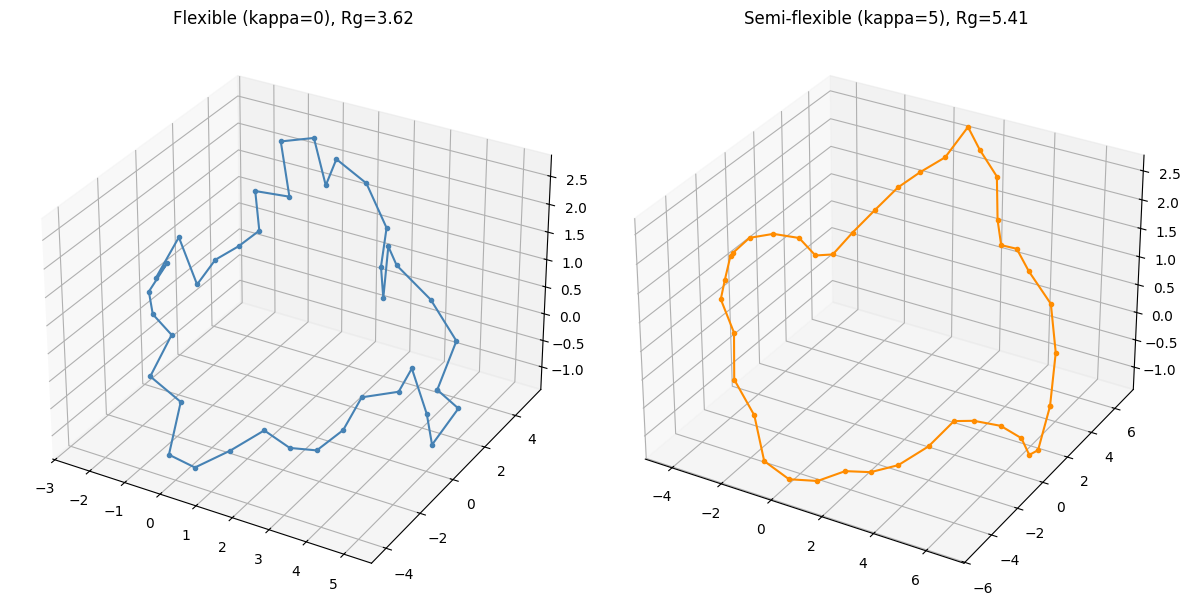

In [ ]:
fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(121, projection='3d')
plot_chain_3d(trajectory[-1], title=f'Flexible (kappa=0), Rg={rg_flexible_final:.2f}', ax=ax1, color='steelblue')
ax2 = fig.add_subplot(122, projection='3d')
plot_chain_3d(trajectory_stiff[-1], title=f'Semi-flexible (kappa=5), Rg={rg_stiff_final:.2f}', ax=ax2, color='darkorange')
plt.tight_layout()
plt.show()

# **G. Seeding with a genuinely knotted configuration**

Everything above started from an unknotted circle. As a sanity check, we seed the simulation with beads placed on the standard $(2,3)$ torus-knot parameterisation of a trefoil (which is provably knotted by contruction and not just by inspection) and check the dynamics.

In [ ]:
pos0_trefoil = ds.make_trefoil_seed(N=60, scale=1.2, seed=0)
bmean0, bstd0, bmin0, bmax0 = ds.bond_length_stats(pos0_trefoil)
print(f'Trefoil seed: mean bond length={bmean0:.3f}, min pairwise dist={ds.min_pairwise_distance(pos0_trefoil):.3f}')

trajectory_trefoil = ds.run_simulation(
    pos0_trefoil, n_steps=30000, dt=0.0001, gamma=1.0, kT=1.0, seed=2, record_every=3000,
    K=30.0, R0=1.5, epsilon=1.0, sigma=1.0, kappa=1.0
)

for i, pos in enumerate(trajectory_trefoil):
    rg = ds.radius_of_gyration(pos)
    mind = ds.min_pairwise_distance(pos)
    print(f'step {i*3000:6d}: Rg={rg:.3f}  min_dist={mind:.3f}  nan={np.isnan(pos).any()}')

Trefoil seed: mean bond length=1.001, min pairwise dist=0.800


step      0: Rg=4.895  min_dist=0.800  nan=False
step   3000: Rg=4.340  min_dist=0.894  nan=False
step   6000: Rg=4.227  min_dist=0.915  nan=False
step   9000: Rg=4.052  min_dist=0.907  nan=False
step  12000: Rg=4.018  min_dist=0.892  nan=False
step  15000: Rg=3.839  min_dist=0.900  nan=False
step  18000: Rg=3.469  min_dist=0.878  nan=False
step  21000: Rg=3.411  min_dist=0.886  nan=False
step  24000: Rg=3.403  min_dist=0.878  nan=False
step  27000: Rg=3.454  min_dist=0.915  nan=False
step  30000: Rg=3.533  min_dist=0.887  nan=False


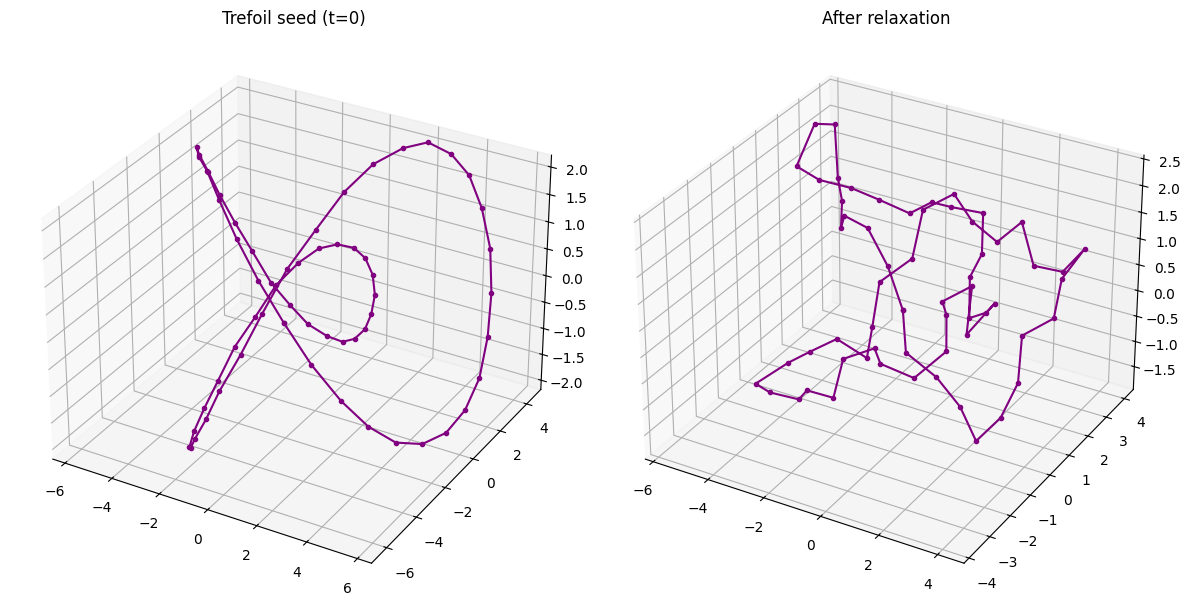

In [ ]:
fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(121, projection='3d')
plot_chain_3d(trajectory_trefoil[0], title='Trefoil seed (t=0)', ax=ax1, color='purple')
ax2 = fig.add_subplot(122, projection='3d')
plot_chain_3d(trajectory_trefoil[-1], title='After relaxation', ax=ax2, color='purple')
plt.tight_layout()
plt.show()

This only checks the simulation doesn't numerically misbehave (no NaNs, no collapse). It does not formally verify the chain is still knotted after relaxation. Under correct dynamics with working excluded volume, topology should be conserved (a continuous deformation without self-crossing cannot change knot type). The classification tools in the next notebooks verify this.

Using this numerically stable simulator, notebook 2 builds the first of the two independent knot classifiers (KMT geometric simplification + Alexander polynomial via the matrix method). We can then label trajectories, like the trefoil run above, with a knot type.